In [80]:
import xarray as xr
import numpy as np

begin_year=2005
fn = "/rd/cenfic3/cenmod/era40/vortex/s2m/alp_allslopes/reanalysis_2020.2/meteo/FORCING_" + str(begin_year)+ "080106_"+ str(begin_year + 1)+ "080106.nc"
local_data= xr.open_dataset(fn)

In [2]:
fn = "FORCING_reanalysis2020.2@lafaysse_alp_allslopes_2005080106_2006080106.nc"
hendrix_data = xr.open_dataset(fn)

In [ ]:
hendrix_data.to_netcdf

In [62]:
local_data

<xarray.Dataset> Size: 2GB
Dimensions:          (Number_of_points: 4471, time: 8761, massif: 24)
Coordinates:
  * time             (time) datetime64[ns] 70kB 2005-08-01T06:00:00 ... 2006-...
  * massif           (massif) float64 192B 1.0 2.0 3.0 4.0 ... 22.0 23.0 30.0
Dimensions without coordinates: Number_of_points
Data variables: (12/24)
    ZS               (Number_of_points) float32 18kB 300.0 300.0 ... 3e+03 3e+03
    aspect           (Number_of_points) float32 18kB ...
    slope            (Number_of_points) float32 18kB ...
    massif_number    (Number_of_points) float64 36kB ...
    PSurf            (time, Number_of_points) float32 157MB ...
    Tair             (time, Number_of_points) float32 157MB ...
    ...               ...
    CO2air           (time, Number_of_points) float32 157MB ...
    FRC_TIME_STP     float32 4B ...
    LAT              (Number_of_points) float64 36kB 46.18 46.18 ... 46.39 46.39
    LON              (Number_of_points) float64 36kB 6.645 6.645 ... 7.303 7.303
    isoZeroAltitude  (time, massif) float64 2MB ...
    rainSnowLimit    (time, massif) float64 2MB ...
Attributes: (12/45)
    id:                            s2m_reanalysis_2020.2
    references:                    https://doi.org/10.1175/2008JAMC1808.1;htt...
    date_created:                  2021-04-30T10:01:00
    platform:                      MODELS_ANALYSES.REANALYSIS_MODELS
    platform_vocabulary:           GCMD,AERIS
    contributor_name:              Matthieu Vernay ; Matthieu Lafaysse
    ...                            ...
    publisher_url:                 https://www.umr-cnrm.fr/spip.php?rubrique85
    creator_url:                   https://www.umr-cnrm.fr/spip.php?rubrique85
    safran_tag:                    s2m_reanalysis_2020.2
    title:                         S2M reanalysis: meteorological variables
    summary:                       This file takes part from a 61-years reana...
    keywords:                      MOUNTAINS,INCOMING SOLAR RADIATION,LONGWAV...

In [ ]:
24*8*2*

In [66]:
local_data.where(local_data.data_vars['massif_number']==1).data_vars('ZS').values

KeyboardInterrupt: 

In [81]:
def generate_xarray_compression_encodings(data: xr.Dataset | xr.DataArray, compression_level: int = 3):
    output_dict = {}
    compression_encoding_dict = {"zlib": True, "complevel": compression_level}
    if type(data) is xr.Dataset:
        for data_var_name in data.data_vars:
            output_dict.update({data_var_name: compression_encoding_dict})
    elif type(data) is xr.DataArray:
        output_dict.update({data.name: compression_encoding_dict})
    return output_dict

compression_encodings = generate_xarray_compression_encodings(local_data)
# local_data.encoding.update(compression_encodings)
local_data.to_netcdf('FORCING_2005_2006_test_storage.nc', encoding=compression_encodings)

In [3]:
for dv in local_data.data_vars:
    print(dv)
    print(np.abs(local_data.data_vars[dv] - hendrix_data.data_vars[dv]).mean().values)
    print(np.abs(local_data.data_vars[dv] - hendrix_data.data_vars[dv]).sum().values)

ZS
0.0
0.0
aspect
0.0
0.0
slope
0.0
0.0
massif_number
0.0
0.0
PSurf
0.0
0.0
Tair
0.0
0.0
Qair
0.0
0.0
Wind_DIR
0.0
0.0
Wind
0.0
0.0
Rainf
0.0
0.0
Snowf


KeyboardInterrupt: 

In [14]:
import xml.etree.ElementTree as ET
metadata_file_path = "/home/imperatoren/work/edelweiss_assimilation/snowtools/snowtools/DATA/METADATA.xml"

tree = ET.parse(metadata_file_path)
root = tree.getroot()
root.attrib

{}

In [46]:
massif_dict = {}
for idx_list_massif in range(len(root[0])):
    massif_dict.update({root[0][idx_list_massif][0].text: {root[0][idx_list_massif][3].tag :root[0][idx_list_massif][3].text,
                                                           root[0][idx_list_massif][4].tag :root[0][idx_list_massif][4].text }, 
                        })

In [85]:
f1 = xr.open_dataset("/home/imperatoren/work/edelweiss_assimilation/simu_s2m/FORCING_2005080106_2006080106.nc")
f2 = xr.open_dataset("/home/imperatoren/work/edelweiss_assimilation/simu_s2m/FORCING_2006080106_2007080106.nc")

In [87]:
xr.concat([f1,f2], dim='time').to_netcdf('test_concat.nc')

/tmp/ipykernel_45392/556094878.py:1: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  xr.concat([f1,f2], dim='time').to_netcdf('test_concat.nc')


In [91]:
xr.open_dataset("/home/imperatoren/work/edelweiss_assimilation/simu_s2m/FORCING_2005080106_2007080106.nc")

<xarray.Dataset> Size: 315MB
Dimensions:        (time: 17522, Number_of_points: 187)
Coordinates:
  * time           (time) datetime64[ns] 140kB 2005-08-01T06:00:00 ... 2007-0...
Dimensions without coordinates: Number_of_points
Data variables: (12/22)
    ZS             (time, Number_of_points) float32 13MB ...
    aspect         (time, Number_of_points) float32 13MB ...
    slope          (time, Number_of_points) float32 13MB ...
    massif_number  (time, Number_of_points) float64 26MB ...
    PSurf          (time, Number_of_points) float32 13MB ...
    Tair           (time, Number_of_points) float32 13MB ...
    ...             ...
    ZREF           (time, Number_of_points) float32 13MB ...
    UREF           (time, Number_of_points) float32 13MB ...
    CO2air         (time, Number_of_points) float32 13MB ...
    FRC_TIME_STP   (time) float32 70kB ...
    LAT            (time, Number_of_points) float64 26MB ...
    LON            (time, Number_of_points) float64 26MB ...
Attributes: (12/50)
    references:                    https://doi.org/10.5194/essd-14-1707-2022
    keywords_vocabulary:           GCMD
    conventions:                   ACDD-1.3,CF-1.7
    naming_authority:              fr.umr-cnrm.cen
    acknowledgement:               Many contributors have developed and maint...
    standard_name_vocabulary:      CF Standard Name Table v67
    ...                            ...
    safran_tag:                    reanalysis_2020
    vortex_tag:                    safran_reanalysis_2020.3
    uenv:                          uenv:safran.reanalysis2024.1@vernaym
    title:                         S2M reanalysis: meteorological variables
    summary:                       This file takes part from a 61-years reana...
    keywords:                      MOUNTAINS,INCOMING SOLAR RADIATION,LONGWAV...

In [4]:
ds

<xarray.Dataset> Size: 853MB
Dimensions:        (Number_of_points: 187, time: 87658)
Coordinates:
  * time           (time) datetime64[ns] 701kB 2005-08-01T06:00:00 ... 2015-0...
Dimensions without coordinates: Number_of_points
Data variables: (12/22)
    ZS             (Number_of_points) float32 748B ...
    aspect         (Number_of_points) float32 748B ...
    slope          (Number_of_points) float32 748B ...
    massif_number  (Number_of_points) float64 1kB ...
    PSurf          (time, Number_of_points) float32 66MB ...
    Tair           (time, Number_of_points) float32 66MB ...
    ...             ...
    ZREF           (Number_of_points) float32 748B ...
    UREF           (Number_of_points) float32 748B ...
    CO2air         (time, Number_of_points) float32 66MB ...
    FRC_TIME_STP   float32 4B ...
    LAT            (Number_of_points) float64 1kB ...
    LON            (Number_of_points) float64 1kB ...
Attributes: (12/50)
    references:                    https://doi.org/10.5194/essd-14-1707-2022
    keywords_vocabulary:           GCMD
    conventions:                   ACDD-1.3,CF-1.7
    naming_authority:              fr.umr-cnrm.cen
    acknowledgement:               Many contributors have developed and maint...
    standard_name_vocabulary:      CF Standard Name Table v67
    ...                            ...
    safran_tag:                    reanalysis_2020
    vortex_tag:                    safran_reanalysis_2020.3
    uenv:                          uenv:safran.reanalysis2024.1@vernaym
    title:                         S2M reanalysis: meteorological variables
    summary:                       This file takes part from a 61-years reana...
    keywords:                      MOUNTAINS,INCOMING SOLAR RADIATION,LONGWAV...

/home/imperatoren/miniforge3/envs/snowtools_env/lib/python3.13/site-packages/xarray/groupers.py:530: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  self.index_grouper = pd.Grouper(


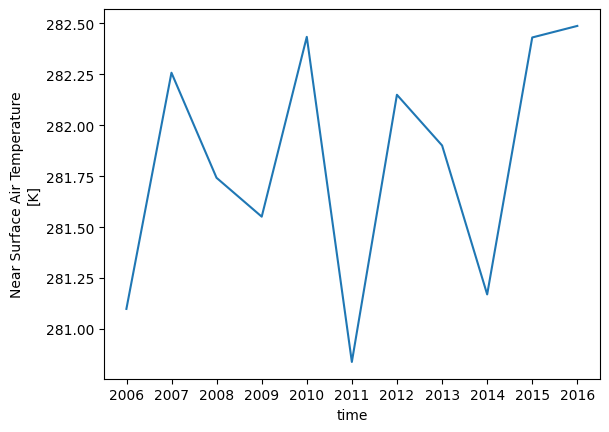

In [17]:
import xarray as xr
ds = xr.open_dataset("/home/imperatoren/work/edelweiss_assimilation/FORCING_2005080106_2015080106.nc")
ds.isel(Number_of_points=25).Tair.resample(time='Y').mean().plot.line()

In [52]:
import xarray as xr
ds = xr.open_dataset("/home/imperatoren/work/edelweiss_assimilation/grandesrousses/spinup/prep/PGD_grandesrousses.nc")
# ds.isel(Number_of_points=25).Tair.resample(time='Y').mean().plot.line()

In [53]:
ds.data_vars

Data variables:
    VERSION       int32 4B ...
    BUG           int32 4B ...
    STORAGETYPE   |S40 40B ...
    SPLIT_PATCH   |S1 1B ...
    SEA           |S40 40B ...
    WATER         |S40 40B ...
    NATURE        |S40 40B ...
    TOWN          |S40 40B ...
    DIM_FULL      int32 4B ...
    DIM_SEA       int32 4B ...
    DIM_NATURE    int32 4B ...
    DIM_WATER     int32 4B ...
    DIM_TOWN      int32 4B ...
    ECOCLIMAP     |S1 1B ...
    ECOSG         |S1 1B ...
    WATER_TO_NAT  |S1 1B ...
    TOWN_TO_ROCK  |S1 1B ...
    TOWN_TO_COVE  |S1 1B ...
    REPLACE_COVE  int32 4B ...
    GARDEN        |S1 1B ...
    DATA_IRRIG    |S1 1B ...
    LCLIM_LAI     |S1 1B ...
    GRID_TYPE     |S40 40B ...
    XX            (Number_of_points) float64 1kB ...
    XY            (Number_of_points) float64 1kB ...
    DX            (Number_of_points) float64 1kB ...
    DY            (Number_of_points) float64 1kB ...
    FRAC_SEA      (Number_of_points) float64 1kB ...
    FRAC_NATURE   (Numbe

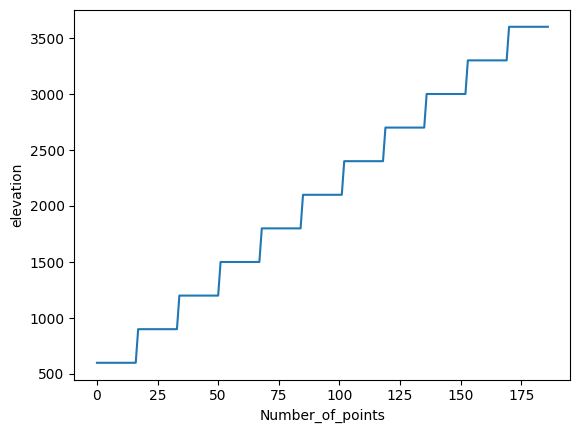

In [51]:
ds.data_vars['ZS'].plot.line()

In [ ]:
import xarray as xr
by=2007
ey=2017
paths = [f"../FORCING_{y}080106_{y+1}080106.nc" for y in range(by,ey)]
data_arrays = [xr.open_dataset(p) for p in paths]
forcing_tot = xr.concat(data_arrays, dim="time", data_vars="minimal")
forcing_tot.to_netcdf(f"../FORCING_{by}080106_{ey}080106.nc")